# 1. Purpose of this notebook

Notebook 01 created the original baseline model. Notebook 02 created five deletion scenarios and full-retraining reference models. Full retraining starts from random parameters and never trains on the training forget set; retain-set fine-tuning instead starts from the original baseline and continues training using retained data only. Fine-tuning should require less time, but the starting parameters may retain influence from deleted training records, so both retained utility and forget quality must be measured.

The experiment addresses three questions:

> Can retain-set fine-tuning approximate full retraining while preserving retained-data utility and requiring less training time?

> How closely do fine-tuned and fully retrained models behave on the training forget set?

> Does fine-tuning behave differently across deletion requests of different sizes and structures?

| Objective | Evaluation data | Main comparison | Measures |
|---|---|---|---|
| Retained utility | Retained test set | Fine-tuning vs baseline and full retraining | Individual utility metrics and Composite Model Utility |
| Forget quality | Training forget set | Fine-tuning vs full retraining | Truth ratio, KS p-value, KS statistic and supporting measures |
| Efficiency | Training process | Fine-tuning vs full retraining | Runtime and speed-up |

The scope is deliberately narrow.

Scenario membership is loaded unchanged from Notebook 02. Every scenario starts from a fresh baseline copy. Fine-tuning uses retained training data only, and retained validation data alone selects the model. Forget and test data do not tune or select models. Full-retraining outputs are comparison references only. This notebook does not perform gradient ascent or SISA. Similarity to full retraining is heuristic evidence, not proof of complete erasure, and generated data does not establish clinical effectiveness.


# 2. Load frozen baseline and full-retraining artefacts

Only local data handling, saved-artifact loading, PyTorch training, evaluation, statistical testing, plotting, timing and persistence libraries are used.


In [1]:
# Import only the libraries required by the established notebook workflow.
import copy
import json
import math
import os
import random
import time
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import Markdown, display
from scipy.stats import ks_2samp


In [2]:
# Import only the libraries required by the established notebook workflow.
from sklearn.metrics import (accuracy_score, average_precision_score, balanced_accuracy_score,
                             confusion_matrix, f1_score, log_loss, precision_score,
                             recall_score, roc_auc_score)
from torch import nn
from torch.utils.data import DataLoader, TensorDataset


All paths are relative to the clean submission workspace; no machine-specific path is embedded in the analysis.


In [3]:
def locate_submission_root():
    candidates = [Path.cwd(), Path.cwd() / "final_submission"]
    candidates += list(Path.cwd().parents)
    for candidate in candidates:
        if (candidate / "data/final/kidney_transplant_assessments.csv").exists():
            return candidate.resolve()
    raise FileNotFoundError("Could not locate final_submission from the current working directory")

# Keep paths portable within the submission workspace
ROOT = locate_submission_root()
DATA_PATH = ROOT / "data/final/kidney_transplant_assessments.csv"
FEATURE_PATH = ROOT / "data/final/classifier_feature_list.json"
SPLIT_PATH = ROOT / "processed_data/split_assignments.csv"
MEMBERSHIP_PATH = ROOT / "processed_data/deletion_scenario_membership.csv"
BASELINE_MODEL_PATH = ROOT / "models/baseline/baseline_model.pt"
BASELINE_PREPROCESSOR_PATH = ROOT / "models/baseline/baseline_preprocessor.joblib"
BASELINE_CONFIG_PATH = ROOT / "models/baseline/model_configuration.json"


In [4]:
FULL_RESULT_DIR = ROOT / "results/full_retraining"
MODEL_DIR = ROOT / "models/retain_set_fine_tuning"
RESULT_DIR = ROOT / "results/retain_set_fine_tuning"
FIGURE_DIR = RESULT_DIR / "figures"
MODEL_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
# Mark the run as incomplete until every final check passes
(RESULT_DIR / "run_summary.json").write_text(
    json.dumps({"status": "running", "task": "retain-set fine-tuning"}, indent=2) + "\n",
    encoding="utf-8",
)

62

Reproducibility controls are fixed before data are loaded.

The fixed seed is reset before each scenario model and loader. CPU execution and deterministic PyTorch behaviour are used.


In [5]:
# Use the same deterministic seed for every scenario
SEED = 42
DEVICE = torch.device("cpu")

def reset_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.use_deterministic_algorithms(True)

reset_seed()
torch.set_num_threads(max(1, min(4, os.cpu_count() or 1)))


The final assessments, approved 18-feature contract, and permanent recipient-level splits are loaded without modification.


In [6]:
# Load the approved data and feature contract without modification
assessments = pd.read_csv(DATA_PATH)
feature_contract = json.loads(FEATURE_PATH.read_text(encoding="utf-8"))
classifier_features = feature_contract.get("classifier_features", feature_contract.get("features"))
if classifier_features is None:
    raise KeyError("Classifier feature list is missing its feature array")
target = feature_contract.get("target_column", "acute_rejection_within_30_days")
splits = pd.read_csv(SPLIT_PATH)
assert assessments.shape == (60_000, 31)
assert len(classifier_features) == 18 and set(classifier_features).issubset(assessments.columns)
assert splits["recipient_id"].nunique() == 10_000 and set(splits["split"]) == {"train", "validation", "test"}
split_map = splits.set_index("recipient_id")["split"]
assessments["original_split"] = assessments["recipient_id"].map(split_map)
assert assessments["original_split"].notna().all()


Deletion membership comes directly from Notebook 02.

The saved Notebook 02 membership is the sole authority for training-forget, deleted-validation and deleted-test IDs; retained sets are complements within their permanent split.


In [7]:
# Notebook 02 remains the authority for deletion membership
membership = pd.read_csv(MEMBERSHIP_PATH)
SCENARIOS = ["recipient_withdrawal", "donor_withdrawal", "hospital_removal",
             "invalid_consent", "retention_expiry"]
assert membership.shape[0] == 24_600 and set(membership["scenario"]) == set(SCENARIOS)
assert not membership.duplicated(["scenario", "assessment_id"]).any()

scenario_ids = {}
for scenario in SCENARIOS:
    part = membership[membership["scenario"].eq(scenario)]
    scenario_ids[scenario] = {
        "training_forget": set(part.loc[part["membership_type"].eq("training_forget"), "assessment_id"]),
        "deleted_validation": set(part.loc[part["membership_type"].eq("deleted_validation"), "assessment_id"]),
        "deleted_test": set(part.loc[part["membership_type"].eq("deleted_test"), "assessment_id"]),
    }


The original baseline checkpoint and preprocessor are then loaded unchanged.

The original baseline parameters and fitted representation are reused unchanged. The expected architecture is `24 → 64 → 32 → 1`, with 3,713 parameters and threshold `0.62`.


In [8]:
class BaselineMLP(nn.Module):
    def __init__(self, input_dim=24, hidden_dims=(64, 32), dropout=0.10):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, hidden_dims[0]), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden_dims[0], hidden_dims[1]), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden_dims[1], 1),
        )
    def forward(self, x):
        return self.network(x).squeeze(1)

# Retain-set fine-tuning must begin from the original trained model
baseline_checkpoint = torch.load(BASELINE_MODEL_PATH, map_location=DEVICE, weights_only=False)
baseline_config = json.loads(BASELINE_CONFIG_PATH.read_text(encoding="utf-8"))
baseline_preprocessor = joblib.load(BASELINE_PREPROCESSOR_PATH)
THRESHOLD = float(baseline_config["threshold"])
baseline_model = BaselineMLP().to(DEVICE)


In [9]:
# Fail early if this stage no longer matches the frozen experiment contract.
baseline_model.load_state_dict(baseline_checkpoint["model_state_dict"])
baseline_model.eval()
assert THRESHOLD == 0.62 and sum(p.numel() for p in baseline_model.parameters()) == 3_713
assert len(baseline_preprocessor.get_feature_names_out()) == 24
assert classifier_features == baseline_config["classifier_features"]


Full-retraining results provide the reference behaviour.

Verified Notebook 02 retained-test predictions, utility metrics, forget references, truth ratios, and runtimes are loaded. Full-retraining models are not rerun.


In [10]:
# Full retraining is loaded as the reference, not rerun here
required_reference_files = ["run_summary.json", "scenario_summary.csv", "retained_test_predictions.csv",
                            "utility_metrics.csv", "forget_set_reference_predictions.csv",
                            "truth_ratio_reference_values.csv", "training_summary.csv"]
assert all((FULL_RESULT_DIR / name).exists() for name in required_reference_files)
full_run = json.loads((FULL_RESULT_DIR / "run_summary.json").read_text(encoding="utf-8"))
assert full_run["status"] == "completed" and set(full_run["scenarios"]) == set(SCENARIOS)
scenario_summary = pd.read_csv(FULL_RESULT_DIR / "scenario_summary.csv")
reference_test = pd.read_csv(FULL_RESULT_DIR / "retained_test_predictions.csv")
reference_utility = pd.read_csv(FULL_RESULT_DIR / "utility_metrics.csv")
reference_forget = pd.read_csv(FULL_RESULT_DIR / "forget_set_reference_predictions.csv")
reference_truth = pd.read_csv(FULL_RESULT_DIR / "truth_ratio_reference_values.csv")
reference_training = pd.read_csv(FULL_RESULT_DIR / "training_summary.csv")


Compatibility checks run before any fine-tuning.

The following checks enforce scenario completeness, membership integrity, reference reconciliation, feature compatibility, the fixed threshold and leakage safeguards before training.


In [11]:
# Check compatibility and leakage safeguards before training
direct_identity_fields = {"assessment_id", "recipient_id", "donor_id", "hospital_id"}
check_rows = []


In [12]:
# Visualise established results without using the figure to tune the experiment.
for scenario in SCENARIOS:
    ids = scenario_ids[scenario]
    expected_test = set(assessments.loc[assessments["original_split"].eq("test"), "assessment_id"]) - ids["deleted_test"]
    ref_test_ids = set(reference_test.loc[reference_test["scenario"].eq(scenario), "assessment_id"])
    ref_forget_ids = set(reference_forget.loc[reference_forget["scenario"].eq(scenario), "assessment_id"])
    checks = {
        "scenario_available": scenario in set(full_run["scenarios"]),
        "membership_ids_exist": set().union(*ids.values()).issubset(set(assessments["assessment_id"])),
        "no_membership_duplicates": not membership[membership["scenario"].eq(scenario)].duplicated("assessment_id").any(),
        "forget_count_matches": len(ids["training_forget"]) == len(ref_forget_ids),
        "retained_test_ids_match": expected_test == ref_test_ids,
        "forget_reference_ids_match": ids["training_forget"] == ref_forget_ids,
        "feature_and_threshold_match": classifier_features == baseline_config["classifier_features"] and THRESHOLD == 0.62,
        "no_direct_identity_inputs": direct_identity_fields.isdisjoint(classifier_features),
    }
    check_rows += [{"scenario": scenario, "check": k, "passed": bool(v)} for k, v in checks.items()]


In [13]:
artifact_checks = pd.DataFrame(check_rows)
assert artifact_checks["passed"].all()
display(artifact_checks.pivot(index="scenario", columns="check", values="passed"))


check,feature_and_threshold_match,forget_count_matches,forget_reference_ids_match,membership_ids_exist,no_direct_identity_inputs,no_membership_duplicates,retained_test_ids_match,scenario_available
scenario,,,,,,,,
donor_withdrawal,True,True,True,True,True,True,True,True
hospital_removal,True,True,True,True,True,True,True,True
invalid_consent,True,True,True,True,True,True,True,True
recipient_withdrawal,True,True,True,True,True,True,True,True
retention_expiry,True,True,True,True,True,True,True,True


**Checks before fine-tuning.**

All five scenarios passed compatibility checks. Membership IDs reconcile with permanent splits and Notebook 02 references; feature order, 24-input representation, 3,713-parameter architecture, truth-ratio reference, and threshold `0.62` are available. Direct identity fields are absent from classifier inputs.


# 3. Reconstruct deletion scenarios and retained data

Retain-set fine-tuning is an approximate machine-unlearning method. For each scenario, it starts from a fresh copy of the original baseline model and continues training it using only retained training data. The training forget set is not used for parameter updates or model selection. Because the starting baseline parameters were originally influenced by those records, fine-tuning must be evaluated against a model retrained without them.

Each scenario is reconstructed from the saved membership.

Each retained partition is reconstructed as the complement of the exact saved deletion membership within its permanent split. No duplicate datasets are saved.


In [14]:
# Rebuild retain sets as complements of the saved deletion membership
scenario_frames = {}
for scenario in SCENARIOS:
    ids = scenario_ids[scenario]
    scenario_frames[scenario] = {}
    for split_name, deleted_role in [("train", "training_forget"), ("validation", "deleted_validation"),
                                     ("test", "deleted_test")]:
        base = assessments[assessments["original_split"].eq(split_name)].copy()
        scenario_frames[scenario][f"retained_{split_name}"] = base[~base["assessment_id"].isin(ids[deleted_role])].copy()
    scenario_frames[scenario]["training_forget"] = assessments[
        assessments["assessment_id"].isin(ids["training_forget"])
    ].copy()

count_check = []
summary_by_scenario = scenario_summary.set_index("scenario")


In [15]:
# Fail early if this stage no longer matches the frozen experiment contract.
for scenario, parts in scenario_frames.items():
    expected = summary_by_scenario.loc[scenario]
    actual = {"training_forget_rows": len(parts["training_forget"]),
              "retained_training_rows": len(parts["retained_train"]),
              "retained_validation_rows": len(parts["retained_validation"]),
              "retained_test_rows": len(parts["retained_test"])}
    count_check.append({"scenario": scenario, **actual})
    assert all(actual[k] == int(expected[k]) for k in actual)
display(pd.DataFrame(count_check))


,scenario,training_forget_rows,retained_training_rows,retained_validation_rows,retained_test_rows
0,recipient_withdrawal,426,41598,8904,8898
1,donor_withdrawal,1992,40032,8472,8496
2,hospital_removal,4314,37710,8166,8124
3,invalid_consent,4148,37876,8046,8078
4,retention_expiry,6262,35762,7624,7614


# 4. Prepare retain-set fine-tuning

The original fitted baseline preprocessor transforms retained training, validation, test and training-forget records. It is never refitted because every fine-tuned model begins from parameters learned in that representation.


In [16]:
# Reuse the frozen baseline representation for every model
scenario_matrices = {}
for scenario, parts in scenario_frames.items():
    matrices = {}
    for name, frame in parts.items():
        matrix = baseline_preprocessor.transform(frame[classifier_features]).astype(np.float32)
        labels = frame[target].to_numpy(dtype=np.float32)
        assert matrix.shape == (len(frame), 24)
        assert np.isfinite(matrix).all() and np.isfinite(labels).all()
        matrices[name] = (matrix, labels)
    scenario_matrices[scenario] = matrices


Each scenario starts from its own copy of the original baseline.

Every scenario resets the seed, creates an independent model instance and reloads the identical original baseline state. Initial predictions must match the original baseline before fine-tuning.


In [17]:
# Preserve row order so saved and reference probabilities align.
def predict_probabilities(model, matrix, batch_size=2048):
    model.eval()
    output = []
    with torch.no_grad():
        for start in range(0, len(matrix), batch_size):
            logits = model(torch.from_numpy(matrix[start:start + batch_size]).to(DEVICE))
            output.append(torch.sigmoid(logits).cpu().numpy())
    return np.concatenate(output)

# Give each scenario an independent copy of identical baseline weights
fresh_models = {}
probe = scenario_matrices[SCENARIOS[0]]["retained_train"][0][:256]
baseline_probe = predict_probabilities(baseline_model, probe)


In [18]:
# Fail early if this stage no longer matches the frozen experiment contract.
for scenario in SCENARIOS:
    reset_seed()
    model = BaselineMLP().to(DEVICE)
    model.load_state_dict(copy.deepcopy(baseline_checkpoint["model_state_dict"]))
    assert np.allclose(predict_probabilities(model, probe), baseline_probe, atol=1e-8, rtol=1e-8)
    fresh_models[scenario] = model
assert len({id(model) for model in fresh_models.values()}) == 5


The fine-tuning settings were fixed before forget or test results were examined.

No earlier formal final-submission fine-tuning configuration exists, so the predefined configuration is frozen before forget or test results are examined.

| Setting | Value |
|---|---:|
| Optimizer | AdamW |
| Learning rate | 0.0001 |
| Weight decay | 0.0001 |
| Batch size | 512 |
| Maximum epochs | 30 |
| Early-stopping patience | 5 |
| Loss | Weighted BCE with logits |
| Threshold | 0.62 |
| Device | CPU |


In [19]:
# Keep the predefined fine-tuning configuration fixed across scenarios
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-4
BATCH_SIZE = 512
MAX_EPOCHS = 30
PATIENCE = 5

def make_loader(matrix, labels, shuffle):
    dataset = TensorDataset(torch.from_numpy(matrix), torch.from_numpy(labels))
    generator = torch.Generator().manual_seed(SEED)
    return DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=shuffle, generator=generator)

class_weights = {}
for scenario, matrices in scenario_matrices.items():
    y = matrices["retained_train"][1]
    class_weights[scenario] = float((len(y) - y.sum()) / y.sum())
assert all(np.isfinite(list(class_weights.values())))


# 5. Fine-tune the baseline model

Only retained training batches generate gradients. Retained validation weighted BCE controls early stopping; forget and test records are not accessed during training or selection.


In [20]:
# Use one loss helper for updates and no-gradient validation.
def epoch_loss(model, loader, criterion, optimizer=None):
    model.train(optimizer is not None)
    total, count = 0.0, 0
    context = torch.enable_grad() if optimizer is not None else torch.no_grad()
    with context:
        for xb, yb in loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            if optimizer is not None:
                optimizer.zero_grad(set_to_none=True)
            loss = criterion(model(xb), yb)
            if optimizer is not None:
                loss.backward()
                optimizer.step()
            total += float(loss.item()) * len(yb)
            count += len(yb)
    return total / count

In [21]:
# Exclude training-forget rows from every fine-tuning update.
# Fine-tune on retained training data and select on retained validation data
history_rows, training_rows, fine_tuned_models = [], [], {}


In [22]:
for scenario in SCENARIOS:
    reset_seed()
    model = fresh_models[scenario]
    train_x, train_y = scenario_matrices[scenario]["retained_train"]
    val_x, val_y = scenario_matrices[scenario]["retained_validation"]
    train_loader = make_loader(train_x, train_y, True)
    val_loader = make_loader(val_x, val_y, False)
    criterion = nn.BCEWithLogitsLoss(
        pos_weight=torch.tensor(class_weights[scenario], device=DEVICE)
    )
    optimizer = torch.optim.AdamW(
        model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY
    )
    best_loss, best_state, best_epoch, stale = math.inf, None, 0, 0
    started = time.perf_counter()
    for epoch in range(1, MAX_EPOCHS + 1):
        train_loss = epoch_loss(model, train_loader, criterion, optimizer)
        val_loss = epoch_loss(model, val_loader, criterion)
        # Forget-set results never influence checkpoint selection
        improved = val_loss < best_loss - 1e-12
        if improved:
            best_loss, best_epoch, stale = val_loss, epoch, 0
            best_state = copy.deepcopy(model.state_dict())
        else:
            stale += 1
        history_rows.append({"scenario": scenario, "epoch": epoch,
            "training_weighted_bce": train_loss, "validation_weighted_bce": val_loss,
            "best_so_far": improved})
        if stale >= PATIENCE:
            break
    elapsed = time.perf_counter() - started
    # Restore the checkpoint chosen only by retained validation loss
    model.load_state_dict(best_state)
    model.eval()
    fine_tuned_models[scenario] = model
    training_rows.append({"scenario": scenario, "retained_training_rows": len(train_y),
        "positive_class_weight": class_weights[scenario], "epochs_executed": epoch,
        "best_epoch": best_epoch, "best_validation_weighted_bce": best_loss,
        "training_seconds": elapsed,
        "early_stopping_status": "patience_reached" if stale >= PATIENCE else "maximum_epochs"})

Retained validation loss selects the checkpoint.

The state with the lowest retained-validation weighted BCE is restored for every scenario. No retained-test or forget result participates in epoch selection.


In [23]:
# Fail early if this stage no longer matches the frozen experiment contract.
training_history = pd.DataFrame(history_rows)
training_summary = pd.DataFrame(training_rows)
assert len(fine_tuned_models) == 5
assert (training_summary["best_epoch"] <= training_summary["epochs_executed"]).all()
assert all(sum(p.numel() for p in model.parameters()) == 3_713 for model in fine_tuned_models.values())
display(training_summary)


,scenario,retained_training_rows,positive_class_weight,epochs_executed,best_epoch,best_validation_weighted_bce,training_seconds,early_stopping_status
0,recipient_withdrawal,41598,12.319884,6,1,1.059995,0.961513,patience_reached
1,donor_withdrawal,40032,12.198813,6,1,1.060775,1.012794,patience_reached
2,hospital_removal,37710,12.296897,6,1,1.058121,0.908232,patience_reached
3,invalid_consent,37876,12.914768,9,4,1.047311,1.373795,patience_reached
4,retention_expiry,35762,13.900833,22,17,1.066129,3.194244,patience_reached


Training histories show how retained training and validation loss changed.

The long-format history, concise summary and loss figure show the predefined training process without exposing large intermediate outputs.


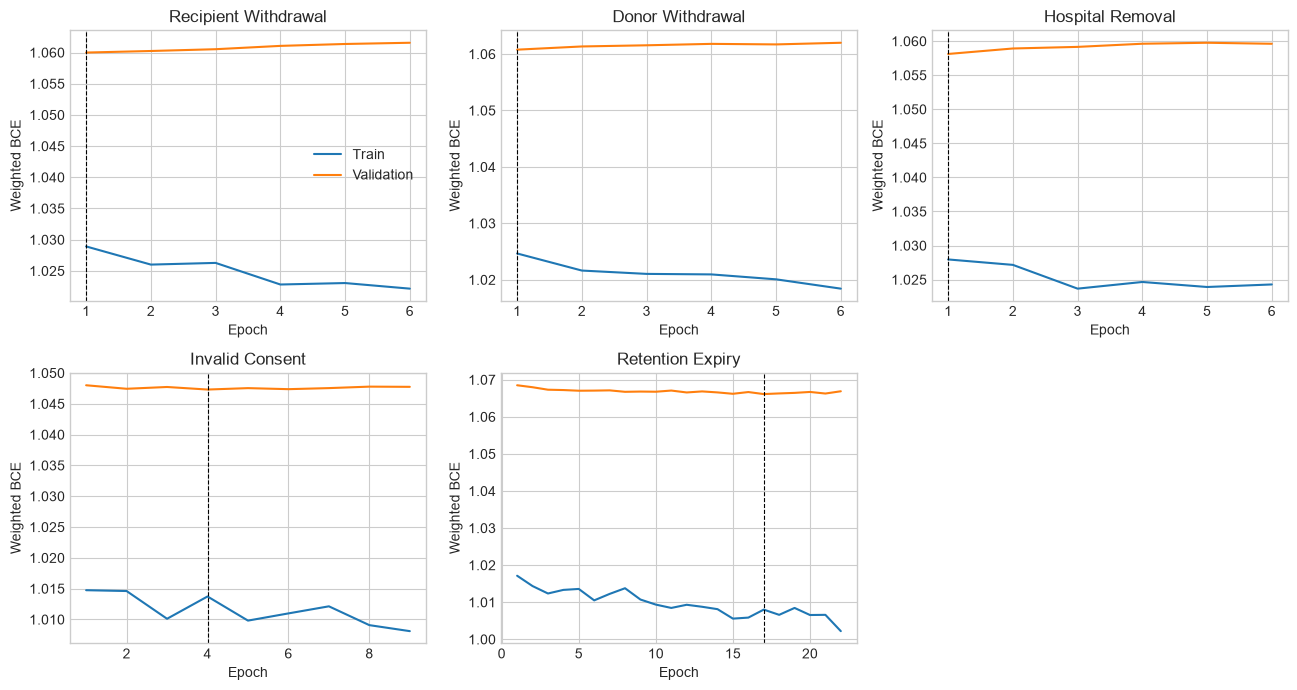

In [24]:
# Keep this training step aligned with the frozen method configuration.
plt.style.use("seaborn-v0_8-whitegrid")
fig, axes = plt.subplots(2, 3, figsize=(13, 7), sharex=False)
for ax, scenario in zip(axes.flat, SCENARIOS):
    part = training_history[training_history["scenario"].eq(scenario)]
    ax.plot(part["epoch"], part["training_weighted_bce"], label="Train")
    ax.plot(part["epoch"], part["validation_weighted_bce"], label="Validation")
    ax.axvline(training_summary.set_index("scenario").loc[scenario, "best_epoch"], color="black", ls="--", lw=0.8)
    ax.set_title(scenario.replace("_", " ").title())
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Weighted BCE")
axes.flat[0].legend()
axes.flat[-1].axis("off")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "fine_tuning_loss_curves.png", dpi=160, bbox_inches="tight")
plt.show()


**Training result.**

Recipient withdrawal, donor withdrawal and hospital removal selected epoch 1; invalid consent selected epoch 4; and retention expiry selected epoch 17. Early best epochs are plausible because fine-tuning starts from the already-trained baseline. These executed results are reported as observations and must not trigger post-hoc hyperparameter tuning.

# 6. Evaluate retained-data utility

Utility measures predictive performance on valid, non-deleted test records. Comparisons within each scenario use identical assessment IDs and threshold `0.62`.

The same utility metrics and fixed threshold used elsewhere in the project are retained.


In [25]:
# PR-AUC reflects rare positives while BCE evaluates probability quality.
def binary_metrics(y, probability, threshold=THRESHOLD):
    prediction = (probability >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y, prediction, labels=[0, 1]).ravel()
    return {"n": len(y), "positive_count": int(y.sum()), "prevalence": float(y.mean()), "threshold": threshold,
            "pr_auc": average_precision_score(y, probability), "auroc": roc_auc_score(y, probability),
            "balanced_accuracy": balanced_accuracy_score(y, prediction), "f1": f1_score(y, prediction, zero_division=0),
            "binary_cross_entropy": log_loss(y, probability, labels=[0, 1]),
            "precision": precision_score(y, prediction, zero_division=0),
            "recall": recall_score(y, prediction, zero_division=0), "specificity": tn / (tn + fp),
            "accuracy": accuracy_score(y, prediction), "positive_prediction_rate": float(prediction.mean()),
            "true_negative": int(tn), "false_positive": int(fp), "false_negative": int(fn), "true_positive": int(tp)}

# Evaluate utility on the same retained test rows used by the references
fine_prediction_frames, fine_metric_rows = [], []


In [26]:
for scenario in SCENARIOS:
    frame = scenario_frames[scenario]["retained_test"].reset_index(drop=True)
    matrix, y = scenario_matrices[scenario]["retained_test"]
    probability = predict_probabilities(fine_tuned_models[scenario], matrix)
    # Keep threshold 0.62 fixed for a fair model comparison
    prediction = (probability >= THRESHOLD).astype(int)
    fine_prediction_frames.append(pd.DataFrame({"scenario": scenario, "evaluation_row": np.arange(len(frame)),
        "true_target": y.astype(int), "fine_tuning_probability": probability, "fine_tuning_prediction": prediction}))
    fine_metric_rows.append({"scenario": scenario, "model": "fine_tuning", **binary_metrics(y, probability)})
fine_predictions = pd.concat(fine_prediction_frames, ignore_index=True)
fine_metrics = pd.DataFrame(fine_metric_rows)


The individual metrics are also summarised by the project’s TOFU-inspired composite.

For baseline, fine-tuned and full-retraining models, `BCE quality = exp(-unweighted BCE)`. **TOFU-inspired Composite Model Utility** is the safeguarded harmonic mean of PR-AUC, AUROC, balanced accuracy, F1 and BCE quality. This adapts the higher-is-better aggregation idea; it does not reproduce TOFU's original language-model utility formula.


In [27]:
# Keep the individual metrics visible alongside the composite summary
utility_metrics = pd.concat([reference_utility.copy(), fine_metrics], ignore_index=True)
utility_metrics["bce_quality"] = np.exp(-utility_metrics["binary_cross_entropy"])
components = ["pr_auc", "auroc", "balanced_accuracy", "f1", "bce_quality"]

def harmonic(values, epsilon=1e-12):
    values = np.asarray(values, dtype=float)
    return float(len(values) / np.sum(1.0 / np.maximum(values, epsilon)))

utility_metrics["composite_model_utility"] = utility_metrics[components].apply(harmonic, axis=1)
composite_utility = utility_metrics[["scenario", "model", *components, "composite_model_utility"]].copy()
assert np.allclose(composite_utility["composite_model_utility"],
                   composite_utility[components].apply(harmonic, axis=1), atol=1e-12, rtol=1e-12)
display(composite_utility)


,scenario,model,pr_auc,auroc,balanced_accuracy,f1,bce_quality,composite_model_utility
0,recipient_withdrawal,baseline,0.169267,0.731534,0.630478,0.244288,0.562843,0.339417
1,donor_withdrawal,baseline,0.168604,0.731754,0.630475,0.244170,0.562930,0.338853
2,hospital_removal,baseline,0.173596,0.739196,0.636655,0.252029,0.563704,0.346601
3,invalid_consent,baseline,0.163900,0.735045,0.628857,0.237052,0.571396,0.332878
4,retention_expiry,baseline,0.167302,0.744495,0.634281,0.252886,0.582390,0.343208
5,recipient_withdrawal,full_retraining,0.177118,0.734572,0.628800,0.234677,0.553877,0.340965
6,donor_withdrawal,full_retraining,0.173580,0.731609,0.633887,0.236778,0.549150,0.338987
7,hospital_removal,full_retraining,0.176205,0.743964,0.641917,0.249229,0.554098,0.347360
8,invalid_consent,full_retraining,0.167787,0.735362,0.637605,0.229071,0.551488,0.331853
9,retention_expiry,full_retraining,0.162155,0.741491,0.627631,0.227008,0.556761,0.326582


The original, fine-tuned and fully retrained models have distinct roles in the comparison.

All comparisons are within scenario because retained-test prevalence can differ across deletion scenarios. Probability metrics use probabilities; threshold-dependent metrics use `0.62`. Lower BCE is better, while its transformed BCE-quality component is higher when better.


In [28]:
# Compare fine-tuning and full retraining on aligned utility metrics.
wide = utility_metrics.pivot(index="scenario", columns="model")
delta_rows = []
comparison_fields = ["pr_auc", "auroc", "balanced_accuracy", "f1", "binary_cross_entropy",
                     "bce_quality", "composite_model_utility"]
for scenario in SCENARIOS:
    row = {"scenario": scenario}
    for metric in comparison_fields:
        fine = wide.loc[scenario, (metric, "fine_tuning")]
        row[f"fine_tuning_minus_baseline_{metric}"] = fine - wide.loc[scenario, (metric, "baseline")]
        row[f"fine_tuning_minus_full_retraining_{metric}"] = fine - wide.loc[scenario, (metric, "full_retraining")]
    delta_rows.append(row)
utility_deltas = pd.DataFrame(delta_rows)
display(utility_metrics[["scenario", "model", *comparison_fields]])


,scenario,model,pr_auc,auroc,balanced_accuracy,f1,binary_cross_entropy,bce_quality,composite_model_utility
0,recipient_withdrawal,baseline,0.169267,0.731534,0.630478,0.244288,0.574755,0.562843,0.339417
1,donor_withdrawal,baseline,0.168604,0.731754,0.630475,0.244170,0.574600,0.562930,0.338853
2,hospital_removal,baseline,0.173596,0.739196,0.636655,0.252029,0.573226,0.563704,0.346601
3,invalid_consent,baseline,0.163900,0.735045,0.628857,0.237052,0.559673,0.571396,0.332878
4,retention_expiry,baseline,0.167302,0.744495,0.634281,0.252886,0.540615,0.582390,0.343208
5,recipient_withdrawal,full_retraining,0.177118,0.734572,0.628800,0.234677,0.590813,0.553877,0.340965
6,donor_withdrawal,full_retraining,0.173580,0.731609,0.633887,0.236778,0.599383,0.549150,0.338987
7,hospital_removal,full_retraining,0.176205,0.743964,0.641917,0.249229,0.590414,0.554098,0.347360
8,invalid_consent,full_retraining,0.167787,0.735362,0.637605,0.229071,0.595136,0.551488,0.331853
9,retention_expiry,full_retraining,0.162155,0.741491,0.627631,0.227008,0.585620,0.556761,0.326582


Results are compared across the five predefined deletion structures.

Deletion size, complete versus partial histories, and clustered versus distributed structures are compared descriptively. Observed differences do not establish causal effects.


In [29]:
# Keep this stage separate so its inputs and checks remain easy to audit.
utility_scenario_comparison = scenario_summary[["scenario", "rows_affected", "full_dataset_percentage",
    "complete_histories_removed", "partial_histories_affected", "structural_type"]].merge(
    composite_utility[composite_utility["model"].eq("fine_tuning")], on="scenario", how="left")
display(utility_scenario_comparison)


,scenario,rows_affected,full_dataset_percentage,complete_histories_removed,partial_histories_affected,structural_type,model,pr_auc,auroc,balanced_accuracy,f1,bce_quality,composite_model_utility
0,recipient_withdrawal,600,0.01,100,0,person-level complete-history,fine_tuning,0.168471,0.731462,0.636580,0.245220,0.556686,0.339028
1,donor_withdrawal,3000,0.05,500,0,linked-entity complete-history,fine_tuning,0.168057,0.731865,0.637464,0.246207,0.557192,0.339172
2,hospital_removal,6000,0.10,1000,0,provider-cluster complete-history,fine_tuning,0.172793,0.739138,0.641841,0.252154,0.558101,0.345881
3,invalid_consent,6000,0.10,0,3800,distributed partial-history,fine_tuning,0.163850,0.735040,0.637867,0.236192,0.561053,0.332281
4,retention_expiry,9000,0.15,0,3700,time-based partial-history,fine_tuning,0.164546,0.744533,0.637844,0.238423,0.562409,0.334213


**Retained-data utility.**

Retained-data utility was broadly preserved rather than uniformly improved. Composite Model Utility remained close to full retraining:

| Scenario | Fine-tuning | Full retraining |
|---|---:|---:|
| Recipient withdrawal | 0.3390 | 0.3410 |
| Donor withdrawal | 0.3392 | 0.3390 |
| Hospital removal | 0.3459 | 0.3474 |
| Invalid consent | 0.3323 | 0.3319 |
| Retention expiry | 0.3342 | 0.3266 |

Individual metrics moved in different directions. The composite therefore must not conceal PR-AUC, AUROC, balanced accuracy, F1 or BCE, and cross-scenario values remain descriptive because retained-test prevalence and membership differ.

# 7. Evaluate forgetting

Forget quality measures whether the fine-tuned model behaves like the full-retraining reference on the training forget set. It does not require forgotten records to receive incorrect or uncertain predictions.

Forgotten records are used only now, after model selection, to evaluate forgetting.

Baseline and fine-tuned probabilities use the baseline preprocessor; full-retraining values come from Notebook 02. Deleted validation and test records are excluded.


In [30]:
# Use forgotten training rows only for evaluation after model selection
forget_frames = []


In [31]:
# Fail early if this stage no longer matches the frozen experiment contract.
for scenario in SCENARIOS:
    frame = scenario_frames[scenario]["training_forget"].reset_index(drop=True)
    matrix, y = scenario_matrices[scenario]["training_forget"]
    fine_probability = predict_probabilities(fine_tuned_models[scenario], matrix)
    ref = reference_forget[reference_forget["scenario"].eq(scenario)].set_index("assessment_id").loc[frame["assessment_id"]]
    truth_ref = reference_truth[reference_truth["scenario"].eq(scenario)].set_index("assessment_id").loc[frame["assessment_id"]]
    assert np.array_equal(ref["true_target"].to_numpy(), y.astype(int))
    out = pd.DataFrame({"scenario": scenario, "evaluation_row": np.arange(len(frame)), "true_target": y.astype(int),
        "baseline_probability": ref["baseline_probability"].to_numpy(), "fine_tuning_probability": fine_probability,
        "full_retraining_probability": ref["full_retraining_probability"].to_numpy(),
        "reference_full_truth_ratio": truth_ref["full_retraining_truth_ratio"].to_numpy()})
    for method in ["baseline", "fine_tuning", "full_retraining"]:
        prob = out[f"{method}_probability"].to_numpy()
        out[f"{method}_prediction"] = (prob >= THRESHOLD).astype(int)
        out[f"{method}_per_record_bce"] = -(y * np.log(np.clip(prob, 1e-12, 1)) + (1-y) * np.log(np.clip(1-prob, 1e-12, 1)))
    forget_frames.append(out)


In [32]:
forget_predictions = pd.concat(forget_frames, ignore_index=True)
assert all(scenario_frames[s]["training_forget"]["original_split"].eq("train").all() for s in SCENARIOS)


Truth ratios compare the probability assigned to the incorrect and true classes.

Notebook 02 defines `p_true` as probability assigned to the true class, `p_incorrect` as the other-class probability, and `truth_ratio = (p_incorrect + epsilon) / (p_true + epsilon)`. The same epsilon is used here.


In [33]:
# Truth Ratio summarises behaviour on the forgotten training records.
EPSILON = float(reference_truth["epsilon"].iloc[0])
truth_frames = []
for method in ["baseline", "fine_tuning", "full_retraining"]:
    # Canonicalise probabilities to float64 before deriving persisted values so
    # the CSV readback calculation follows the same numerical path.
    prob = forget_predictions[f"{method}_probability"].to_numpy(dtype=np.float64)
    y = forget_predictions["true_target"].to_numpy(dtype=np.int64)
    p_true = np.where(y == 1, prob, 1 - prob)
    p_incorrect = 1 - p_true
    ratio = (p_incorrect + EPSILON) / (p_true + EPSILON)
    truth_frames.append(pd.DataFrame({"scenario": forget_predictions["scenario"],
        "evaluation_row": forget_predictions["evaluation_row"], "true_target": y, "model": method,
        "p_true": p_true, "p_incorrect": p_incorrect, "truth_ratio": ratio, "epsilon": EPSILON}))
truth_ratio_values = pd.concat(truth_frames, ignore_index=True)
full_ratio = truth_ratio_values[truth_ratio_values["model"].eq("full_retraining")]["truth_ratio"].to_numpy()
assert np.allclose(full_ratio, forget_predictions["reference_full_truth_ratio"], atol=1e-10, rtol=1e-10)


In [34]:
# Keep this stage separate so its inputs and checks remain easy to audit.
truth_ratio_summary = truth_ratio_values.groupby(["scenario", "model"])["truth_ratio"].agg(
    count="count", mean="mean", median="median", minimum="min", maximum="max",
    q1=lambda x: x.quantile(.25), q3=lambda x: x.quantile(.75)).reset_index()
truth_ratio_summary["interquartile_range"] = truth_ratio_summary["q3"] - truth_ratio_summary["q1"]
display(truth_ratio_summary)


,scenario,model,count,mean,median,minimum,maximum,q1,q3,interquartile_range
0,donor_withdrawal,baseline,1992,0.979881,0.906640,3.574875e-09,6.985770,0.390317,1.388092,0.997774
1,donor_withdrawal,fine_tuning,1992,1.015556,0.917704,3.442744e-09,7.737382,0.381329,1.430981,1.049652
2,donor_withdrawal,full_retraining,1992,1.065314,0.963850,1.271374e-07,7.135536,0.417091,1.516182,1.099091
3,hospital_removal,baseline,4314,0.935517,0.810691,1.652883e-09,8.626322,0.310622,1.343399,1.032777
4,hospital_removal,fine_tuning,4314,0.969649,0.823250,1.504561e-09,9.838072,0.309193,1.390201,1.081007
5,hospital_removal,full_retraining,4314,1.011090,0.882400,4.613736e-09,10.233602,0.308297,1.430740,1.122443
6,invalid_consent,baseline,4148,1.147995,0.983963,3.762437e-05,7.181721,0.678249,1.423157,0.744908
7,invalid_consent,fine_tuning,4148,1.206731,0.998091,2.901323e-05,9.602038,0.658343,1.506053,0.847710
8,invalid_consent,full_retraining,4148,1.261086,1.043372,1.057704e-04,10.187212,0.700872,1.554443,0.853571
9,recipient_withdrawal,baseline,426,0.884839,0.792692,2.283690e-09,5.282698,0.278302,1.211507,0.933205


The two-sample KS test compares fine-tuning with full retraining.

For each scenario, **TOFU-style Forget Quality** is the two-sample KS p-value comparing fine-tuning and full-retraining truth-ratio distributions; KS statistic is the distribution-distance effect size. Higher p-value means less evidence of difference, while lower statistic means smaller observed distance. TOFU uses the p-value as its Forget Quality score, but it depends on sample size, does not prove equivalence or complete erasure, and must not rank models alone.


In [35]:
# Keep the KS statistic beside its sample-size-sensitive p-value.
# Compare truth-ratio distributions with full retraining as the reference
forget_quality_rows = []
for scenario in SCENARIOS:
    subset = truth_ratio_values[truth_ratio_values["scenario"].eq(scenario)]
    fine = subset.loc[subset["model"].eq("fine_tuning"), "truth_ratio"].to_numpy()
    full = subset.loc[subset["model"].eq("full_retraining"), "truth_ratio"].to_numpy()
    result = ks_2samp(fine, full, alternative="two-sided", method="auto")
    forget_quality_rows.append({"scenario": scenario, "forget_rows": len(fine),
        "tofu_style_forget_quality": float(result.pvalue), "ks_statistic": float(result.statistic)})
forget_quality = pd.DataFrame(forget_quality_rows)
display(forget_quality)


,scenario,forget_rows,tofu_style_forget_quality,ks_statistic
0,recipient_withdrawal,426,0.791206,0.044601
1,donor_withdrawal,1992,0.002930,0.057229
2,hospital_removal,4314,0.000924,0.042188
3,invalid_consent,4148,0.007617,0.036644
4,retention_expiry,6262,0.000041,0.041520


Supporting probability and prediction comparisons give context to the KS result.

Similarity to full retraining is supported by probability, prediction and loss comparisons. Changes from baseline are descriptive and are not direct proof of forgetting.


In [36]:
# Retain supporting probability distances beside the KS result.
support_rows = []
for scenario in SCENARIOS:
    part = forget_predictions[forget_predictions["scenario"].eq(scenario)]
    support_rows.append({"scenario": scenario,
        "mean_absolute_probability_difference_from_full": np.mean(np.abs(part["fine_tuning_probability"] - part["full_retraining_probability"])),
        "median_absolute_probability_difference_from_full": np.median(np.abs(part["fine_tuning_probability"] - part["full_retraining_probability"])),
        "prediction_agreement_with_full": np.mean(part["fine_tuning_prediction"] == part["full_retraining_prediction"]),
        "mean_absolute_loss_difference_from_full": np.mean(np.abs(part["fine_tuning_per_record_bce"] - part["full_retraining_per_record_bce"])),
        "mean_probability_change_from_baseline": np.mean(part["fine_tuning_probability"] - part["baseline_probability"]),
        "prediction_changed_from_baseline_pct": 100*np.mean(part["fine_tuning_prediction"] != part["baseline_prediction"])})
supporting_forget = pd.DataFrame(support_rows)
display(supporting_forget)


,scenario,mean_absolute_probability_difference_from_full,median_absolute_probability_difference_from_full,prediction_agreement_with_full,mean_absolute_loss_difference_from_full,mean_probability_change_from_baseline,prediction_changed_from_baseline_pct
0,recipient_withdrawal,0.022302,0.014684,0.957746,0.046978,0.005901,1.408451
1,donor_withdrawal,0.020881,0.015937,0.949297,0.044603,0.004751,2.158635
2,hospital_removal,0.023887,0.017818,0.942049,0.052024,0.005138,1.390821
3,invalid_consent,0.027885,0.021936,0.938525,0.061031,0.006052,3.302797
4,retention_expiry,0.032844,0.026362,0.923028,0.075477,0.012361,5.461514


The five scenarios are compared cautiously because their forget sets differ in size and structure.

Forget-set size and structural differences are reported cautiously; p-values and distances are interpreted together.


In [37]:
forget_comparison = forget_quality.merge(supporting_forget, on="scenario")
display(forget_comparison)


,scenario,forget_rows,tofu_style_forget_quality,ks_statistic,mean_absolute_probability_difference_from_full,median_absolute_probability_difference_from_full,prediction_agreement_with_full,mean_absolute_loss_difference_from_full,mean_probability_change_from_baseline,prediction_changed_from_baseline_pct
0,recipient_withdrawal,426,0.791206,0.044601,0.022302,0.014684,0.957746,0.046978,0.005901,1.408451
1,donor_withdrawal,1992,0.002930,0.057229,0.020881,0.015937,0.949297,0.044603,0.004751,2.158635
2,hospital_removal,4314,0.000924,0.042188,0.023887,0.017818,0.942049,0.052024,0.005138,1.390821
3,invalid_consent,4148,0.007617,0.036644,0.027885,0.021936,0.938525,0.061031,0.006052,3.302797
4,retention_expiry,6262,0.000041,0.041520,0.032844,0.026362,0.923028,0.075477,0.012361,5.461514


**Forget-set results.**

| Scenario | KS p-value | KS statistic |
|---|---:|---:|
| Recipient withdrawal | 0.791206 | 0.044601 |
| Donor withdrawal | 0.002930 | 0.057229 |
| Hospital removal | 0.000924 | 0.042188 |
| Invalid consent | 0.007617 | 0.036644 |
| Retention expiry | 0.000041 | 0.041520 |

Recipient withdrawal produced the least evidence of a difference from full retraining, but this is not proof of equivalence, successful erasure or privacy. Its smaller forget set of 426 rows gives the KS test less statistical power. The other four scenarios produced statistically detectable differences. All KS statistics remained relatively small, so the distributional differences were detectable but not necessarily large. Fine-tuning therefore approximated full-retraining probabilities reasonably closely but did not consistently reproduce its forget-set truth-ratio distribution. No forget result influenced training or model selection.

# 8. Compare with full retraining

Training-phase wall-clock times use equivalent scopes. Speed-up is full-retraining time divided by fine-tuning time; time reduction is the relative difference.


In [38]:
# Compare training-phase wall-clock time on equivalent scopes
efficiency = training_summary.merge(reference_training[["scenario", "training_seconds", "epochs_executed", "best_epoch"]],
    on="scenario", suffixes=("_fine_tuning", "_full_retraining"))
efficiency["speed_up"] = efficiency["training_seconds_full_retraining"] / efficiency["training_seconds_fine_tuning"]
efficiency["time_reduction_pct"] = 100 * (efficiency["training_seconds_full_retraining"] -
    efficiency["training_seconds_fine_tuning"]) / efficiency["training_seconds_full_retraining"]
display(efficiency)


,scenario,retained_training_rows,positive_class_weight,epochs_executed_fine_tuning,best_epoch_fine_tuning,best_validation_weighted_bce,training_seconds_fine_tuning,early_stopping_status,training_seconds_full_retraining,epochs_executed_full_retraining,best_epoch_full_retraining,speed_up,time_reduction_pct
0,recipient_withdrawal,41598,12.319884,6,1,1.059995,0.961513,patience_reached,3.923029,24,12,4.080058,75.490544
1,donor_withdrawal,40032,12.198813,6,1,1.060775,1.012794,patience_reached,3.450068,22,10,3.406486,70.644237
2,hospital_removal,37710,12.296897,6,1,1.058121,0.908232,patience_reached,3.847863,26,14,4.236650,76.396448
3,invalid_consent,37876,12.914768,9,4,1.047311,1.373795,patience_reached,3.528170,24,12,2.568191,61.062093
4,retention_expiry,35762,13.900833,22,17,1.066129,3.194244,patience_reached,3.111061,23,11,0.973958,-2.673800


Utility and truth-ratio distance are shown together without combining them into one score.

The cross-scenario plot uses Composite Model Utility on the horizontal axis and KS statistic on the vertical axis; lower KS statistic indicates greater observed similarity to full retraining. KS p-values remain in the result table but should not be ranked across scenarios with unequal forget-set sizes.

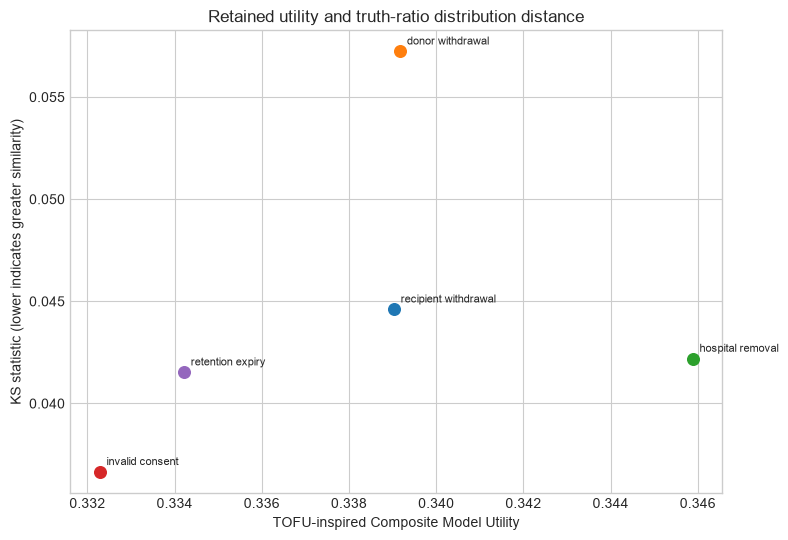

In [39]:
# Plot retained utility against forgetting distance as separate outcomes.
trade_plot = composite_utility[composite_utility["model"].eq("fine_tuning")].merge(
    forget_quality, on="scenario"
)
fig, ax = plt.subplots(figsize=(8, 5.5))
for _, row in trade_plot.iterrows():
    ax.scatter(row["composite_model_utility"], row["ks_statistic"], s=70)
    ax.annotate(row["scenario"].replace("_", " "),
                (row["composite_model_utility"], row["ks_statistic"]),
                xytext=(5, 5), textcoords="offset points", fontsize=8)
ax.set_xlabel("TOFU-inspired Composite Model Utility")
ax.set_ylabel("KS statistic (lower indicates greater similarity)")
ax.set_title("Retained utility and truth-ratio distribution distance")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "utility_vs_forget_quality.png", dpi=160, bbox_inches="tight")
plt.show()

The final comparison keeps utility, forgetting and efficiency as separate outcomes.

No arbitrary combined score merges utility, forgetting and runtime.


In [40]:
# Calculate the established evaluation outputs without changing model selection.
fine_utility = utility_metrics[utility_metrics["model"].eq("fine_tuning")].copy()
combined_tradeoff = scenario_summary[["scenario", "full_dataset_percentage"]].merge(
    fine_utility[["scenario", "pr_auc", "auroc", "balanced_accuracy", "f1", "binary_cross_entropy",
                  "composite_model_utility"]], on="scenario").merge(forget_comparison, on="scenario").merge(
    efficiency[["scenario", "training_seconds_fine_tuning", "training_seconds_full_retraining", "speed_up"]], on="scenario")
display(combined_tradeoff)


,scenario,full_dataset_percentage,pr_auc,auroc,balanced_accuracy,f1,binary_cross_entropy,composite_model_utility,forget_rows,tofu_style_forget_quality,ks_statistic,mean_absolute_probability_difference_from_full,median_absolute_probability_difference_from_full,prediction_agreement_with_full,mean_absolute_loss_difference_from_full,mean_probability_change_from_baseline,prediction_changed_from_baseline_pct,training_seconds_fine_tuning,training_seconds_full_retraining,speed_up
0,recipient_withdrawal,0.01,0.168471,0.731462,0.636580,0.245220,0.585753,0.339028,426,0.791206,0.044601,0.022302,0.014684,0.957746,0.046978,0.005901,1.408451,0.961513,3.923029,4.080058
1,donor_withdrawal,0.05,0.168057,0.731865,0.637464,0.246207,0.584846,0.339172,1992,0.002930,0.057229,0.020881,0.015937,0.949297,0.044603,0.004751,2.158635,1.012794,3.450068,3.406486
2,hospital_removal,0.10,0.172793,0.739138,0.641841,0.252154,0.583215,0.345881,4314,0.000924,0.042188,0.023887,0.017818,0.942049,0.052024,0.005138,1.390821,0.908232,3.847863,4.236650
3,invalid_consent,0.10,0.163850,0.735040,0.637867,0.236192,0.577941,0.332281,4148,0.007617,0.036644,0.027885,0.021936,0.938525,0.061031,0.006052,3.302797,1.373795,3.528170,2.568191
4,retention_expiry,0.15,0.164546,0.744533,0.637844,0.238423,0.575526,0.334213,6262,0.000041,0.041520,0.032844,0.026362,0.923028,0.075477,0.012361,5.461514,3.194244,3.111061,0.973958


Runtime wording is generated from the executed timing table because wall-clock measurements are hardware-dependent.

In [41]:
# Descriptive threshold for interpreting noisy wall-clock timings only.
# It does not affect training, model selection, or any scientific metric.
MEANINGFUL_SPEEDUP = 1.10

runtime_lines = []
faster_scenarios, no_advantage_scenarios = [], []
no_advantage_speedups = []


In [42]:
# Fail early if this stage no longer matches the frozen experiment contract.
for _, row in efficiency.iterrows():
    scenario_label = row["scenario"].replace("_", " ").capitalize()
    fine_time = float(row["training_seconds_fine_tuning"])
    full_time = float(row["training_seconds_full_retraining"])
    speed_up = full_time / fine_time
    time_reduction_pct = 100 * (full_time - fine_time) / full_time
    assert np.isclose(speed_up, row["speed_up"], atol=1e-12, rtol=1e-12)
    assert np.isclose(time_reduction_pct, row["time_reduction_pct"], atol=1e-12, rtol=1e-12)
    if speed_up >= MEANINGFUL_SPEEDUP:
        runtime_interpretation = "fine-tuning was meaningfully faster"
        faster_scenarios.append(scenario_label)
    elif speed_up > 1:
        runtime_interpretation = "fine-tuning was slightly faster, with no meaningful efficiency advantage"
        no_advantage_scenarios.append(scenario_label)
        no_advantage_speedups.append(speed_up)
    elif np.isclose(speed_up, 1, atol=0.01):
        runtime_interpretation = "runtime was approximately equal"
        no_advantage_scenarios.append(scenario_label)
        no_advantage_speedups.append(speed_up)
    else:
        runtime_interpretation = "fine-tuning was slower"
        no_advantage_scenarios.append(scenario_label)
        no_advantage_speedups.append(speed_up)
    runtime_lines.append(
        f"- **{scenario_label}:** fine-tuning **{fine_time:.2f}s**; full retraining "
        f"**{full_time:.2f}s**; speed-up **{speed_up:.2f}×**; time reduction "
        f"**{time_reduction_pct:.1f}%**; {runtime_interpretation}."
    )


In [43]:
# Keep this stage separate so its inputs and checks remain easy to audit.

count_words = {0: "zero", 1: "one", 2: "two", 3: "three", 4: "four", 5: "five"}
meaningful_summary = (
    f"Fine-tuning was meaningfully faster in {count_words[len(faster_scenarios)]} scenarios."
)


In [44]:
# Keep this stage separate so its inputs and checks remain easy to audit.
if no_advantage_scenarios:
    if len(no_advantage_scenarios) == 1:
        no_advantage_names = no_advantage_scenarios[0]
    elif len(no_advantage_scenarios) == 2:
        no_advantage_names = " and ".join(no_advantage_scenarios)
    else:
        no_advantage_names = ", ".join(no_advantage_scenarios[:-1]) + ", and " + no_advantage_scenarios[-1]
    small_runtime_difference = all(
        0.90 <= value < MEANINGFUL_SPEEDUP for value in no_advantage_speedups
    )
    if small_runtime_difference:
        no_advantage_summary = (
            f"{no_advantage_names} showed only a small runtime difference and no meaningful "
            "efficiency advantage in this execution."
        )
    else:
        no_advantage_summary = (
            f"{no_advantage_names} showed no meaningful efficiency advantage in this execution."
        )
    runtime_summary_sentence = meaningful_summary + " " + no_advantage_summary
else:
    runtime_summary_sentence = meaningful_summary


In [45]:
# Calculate the established evaluation outputs without changing model selection.

runtime_finding = (
    "The combined table keeps utility, KS evidence and runtime separate. The descriptive "
    f"meaningful-speed-up threshold is **{MEANINGFUL_SPEEDUP:.2f}×** and applies only to noisy "
    "wall-clock interpretation; it does not affect training, selection or scientific metrics.\n\n"
    + "\n".join(runtime_lines)
    + "\n\n" + runtime_summary_sentence + " Runtime is hardware-dependent and is regenerated on "
      "every execution; no result is selected using a combined trade-off score."
)
display(Markdown(runtime_finding))

The combined table keeps utility, KS evidence and runtime separate. The descriptive meaningful-speed-up threshold is **1.10×** and applies only to noisy wall-clock interpretation; it does not affect training, selection or scientific metrics.

- **Recipient withdrawal:** fine-tuning **0.96s**; full retraining **3.92s**; speed-up **4.08×**; time reduction **75.5%**; fine-tuning was meaningfully faster.
- **Donor withdrawal:** fine-tuning **1.01s**; full retraining **3.45s**; speed-up **3.41×**; time reduction **70.6%**; fine-tuning was meaningfully faster.
- **Hospital removal:** fine-tuning **0.91s**; full retraining **3.85s**; speed-up **4.24×**; time reduction **76.4%**; fine-tuning was meaningfully faster.
- **Invalid consent:** fine-tuning **1.37s**; full retraining **3.53s**; speed-up **2.57×**; time reduction **61.1%**; fine-tuning was meaningfully faster.
- **Retention expiry:** fine-tuning **3.19s**; full retraining **3.11s**; speed-up **0.97×**; time reduction **-2.7%**; fine-tuning was slower.

Fine-tuning was meaningfully faster in four scenarios. Retention expiry showed only a small runtime difference and no meaningful efficiency advantage in this execution. Runtime is hardware-dependent and is regenerated on every execution; no result is selected using a combined trade-off score.

# 9. Save and verify artefacts

One model state and one concise configuration are saved per scenario. The shared baseline preprocessor is referenced rather than duplicated.


In [46]:
# Save the selected checkpoint for each deletion scenario
for scenario, model in fine_tuned_models.items():
    row = training_summary.set_index("scenario").loc[scenario]
    checkpoint = {"model_state_dict": model.state_dict(), "input_dim": 24, "hidden_dims": [64, 32],
                  "dropout": 0.10, "scenario": scenario, "best_epoch": int(row["best_epoch"]),
                  "threshold": THRESHOLD, "seed": SEED}
    torch.save(checkpoint, MODEL_DIR / f"{scenario}_model.pt")
    config = {"scenario": scenario, "baseline_source": "models/baseline/baseline_model.pt",
              "preprocessor_source": "models/baseline/baseline_preprocessor.joblib",
              "classifier_features": classifier_features, "architecture": [24, 64, 32, 1],
              "parameter_count": 3713, "optimizer": "AdamW", "learning_rate": LEARNING_RATE,
              "weight_decay": WEIGHT_DECAY, "batch_size": BATCH_SIZE, "maximum_epochs": MAX_EPOCHS,
              "early_stopping_patience": PATIENCE, "best_epoch": int(row["best_epoch"]),
              "positive_class_weight": float(row["positive_class_weight"]), "threshold": THRESHOLD,
              "seed": SEED, "training_seconds": float(row["training_seconds"])}
    (MODEL_DIR / f"{scenario}_configuration.json").write_text(json.dumps(config, indent=2) + "\n", encoding="utf-8")


Result tables are saved before being read back and independently checked.

Combined machine-readable artifacts are saved with consistent scenario labels. Lightweight reload and recalculation checks avoid rerunning the evaluation.


In [47]:
# Persist the tables needed for later method comparisons
outputs = {
    "training_history.csv": training_history, "training_summary.csv": training_summary,
    "retained_test_predictions.csv": fine_predictions, "utility_metrics.csv": utility_metrics,
    "composite_model_utility.csv": composite_utility, "utility_deltas.csv": utility_deltas,
    "forget_set_predictions.csv": forget_predictions, "truth_ratio_values.csv": truth_ratio_values,
    "truth_ratio_summary.csv": truth_ratio_summary, "forget_quality.csv": forget_comparison,
    "efficiency_comparison.csv": efficiency, "combined_tradeoff.csv": combined_tradeoff,
}
for name, frame in outputs.items():
    frame.to_csv(RESULT_DIR / name, index=False, float_format="%.17g")

**CSV readback.**

All saved comparison tables are reloaded before any downstream verification.

In [48]:
# Read saved tables back before declaring the run complete
saved_truth = pd.read_csv(RESULT_DIR / "truth_ratio_values.csv")
saved_forget_quality = pd.read_csv(RESULT_DIR / "forget_quality.csv")
saved_utility = pd.read_csv(RESULT_DIR / "utility_metrics.csv")
saved_fine_predictions = pd.read_csv(RESULT_DIR / "retained_test_predictions.csv")
saved_forget_predictions = pd.read_csv(RESULT_DIR / "forget_set_predictions.csv")
csv_readback_pass = (
    len(saved_fine_predictions) == len(fine_predictions)
    and len(saved_forget_predictions) == len(forget_predictions)
    and len(saved_truth) == len(truth_ratio_values)
    and set(saved_fine_predictions["scenario"]) == set(SCENARIOS)
    and set(saved_forget_predictions["scenario"]) == set(SCENARIOS)
)
assert csv_readback_pass

**Truth-ratio reproduction.**

Persisted truth ratios are recalculated from persisted float64 probabilities and epsilon.

In [49]:
# Recalculate persisted truth ratios from their saved components
reproduced_truth_ratio = (
    (saved_truth["p_incorrect"] + saved_truth["epsilon"])
    / (saved_truth["p_true"] + saved_truth["epsilon"])
)
truth_ratio_difference = np.abs(saved_truth["truth_ratio"] - reproduced_truth_ratio)
truth_ratio_reproduction_pass = bool(np.allclose(
    saved_truth["truth_ratio"], reproduced_truth_ratio, atol=1e-8, rtol=0
))
truth_ratio_diagnostic = pd.DataFrame([{
    "rows": len(saved_truth),
    "maximum_absolute_difference": float(truth_ratio_difference.max()),
    "required_tolerance": 1e-8,
    "pass": truth_ratio_reproduction_pass,
}])


In [50]:
# Fail early if this stage no longer matches the frozen experiment contract.
truth_ratio_diagnostic.to_csv(
    RESULT_DIR / "truth_ratio_reproduction_diagnostic.csv",
    index=False, float_format="%.17g",
)
display(truth_ratio_diagnostic)
assert truth_ratio_reproduction_pass

,rows,maximum_absolute_difference,required_tolerance,pass
0,51426,1.065814e-14,1.000000e-08,True


**KS reproduction.**

Every saved KS statistic and p-value is recalculated from the reloaded truth-ratio table.

In [51]:
# Reproduce every KS statistic and p-value from the saved ratios
saved_forget_quality_by_scenario = saved_forget_quality.set_index("scenario")
ks_check_rows = []


In [52]:
# Keep this stage separate so its inputs and checks remain easy to audit.
for scenario in SCENARIOS:
    part = saved_truth[saved_truth["scenario"].eq(scenario)]
    ks = ks_2samp(
        part.loc[part["model"].eq("fine_tuning"), "truth_ratio"],
        part.loc[part["model"].eq("full_retraining"), "truth_ratio"],
    )
    saved = saved_forget_quality_by_scenario.loc[scenario]
    ks_check_rows.append({
        "scenario": scenario,
        "statistic_pass": bool(np.isclose(
            ks.statistic, saved["ks_statistic"], atol=1e-12, rtol=1e-12
        )),
        "pvalue_pass": bool(np.isclose(
            ks.pvalue, saved["tofu_style_forget_quality"], atol=1e-12, rtol=1e-12
        )),
    })


In [53]:
# Fail early if this stage no longer matches the frozen experiment contract.
ks_checks = pd.DataFrame(ks_check_rows)
ks_reproduction_pass = bool(ks_checks[["statistic_pass", "pvalue_pass"]].to_numpy().all())
display(ks_checks)
assert ks_reproduction_pass

,scenario,statistic_pass,pvalue_pass
0,recipient_withdrawal,True,True
1,donor_withdrawal,True,True
2,hospital_removal,True,True
3,invalid_consent,True,True
4,retention_expiry,True,True


**Model-output reproduction.**

Each saved model is loaded into a fresh architecture and evaluated through the approved baseline preprocessor on both retained-test and training-forget rows.

In [54]:
# Reload each checkpoint independently and reproduce both prediction sets
reloaded_preprocessor = joblib.load(BASELINE_PREPROCESSOR_PATH)
reload_rows = []


In [55]:
# Load frozen inputs so this stage reuses rather than regenerates earlier evidence.
for scenario in SCENARIOS:
    checkpoint = torch.load(
        MODEL_DIR / f"{scenario}_model.pt", map_location=DEVICE, weights_only=False
    )
    configuration = json.loads(
        (MODEL_DIR / f"{scenario}_configuration.json").read_text(encoding="utf-8")
    )
    reloaded_model = BaselineMLP(
        checkpoint["input_dim"], tuple(checkpoint["hidden_dims"]), checkpoint["dropout"]
    ).to(DEVICE)
    reloaded_model.load_state_dict(checkpoint["model_state_dict"])
    test_matrix = scenario_matrices[scenario]["retained_test"][0]
    forget_matrix = scenario_matrices[scenario]["training_forget"][0]
    test_reproduced = predict_probabilities(reloaded_model, test_matrix).astype(np.float64)
    forget_reproduced = predict_probabilities(reloaded_model, forget_matrix).astype(np.float64)
    test_saved = saved_fine_predictions.loc[
        saved_fine_predictions["scenario"].eq(scenario), "fine_tuning_probability"
    ].to_numpy(dtype=np.float64)
    forget_saved = saved_forget_predictions.loc[
        saved_forget_predictions["scenario"].eq(scenario), "fine_tuning_probability"
    ].to_numpy(dtype=np.float64)
    metadata_pass = (
        checkpoint["scenario"] == configuration["scenario"] == scenario
        and checkpoint["threshold"] == configuration["threshold"] == THRESHOLD
        and [checkpoint["input_dim"], *checkpoint["hidden_dims"], 1] == configuration["architecture"] == [24, 64, 32, 1]
        and configuration["classifier_features"] == classifier_features
        and configuration["parameter_count"] == sum(p.numel() for p in reloaded_model.parameters()) == 3_713
    )
    reload_rows.append({"scenario": scenario,
        "retained_test_max_abs_difference": float(np.max(np.abs(test_reproduced - test_saved))),
        "training_forget_max_abs_difference": float(np.max(np.abs(forget_reproduced - forget_saved))),
        "retained_test_probability_pass": bool(np.allclose(test_saved, test_reproduced, atol=1e-8, rtol=1e-8)),
        "training_forget_probability_pass": bool(np.allclose(forget_saved, forget_reproduced, atol=1e-8, rtol=1e-8)),
        "metadata_pass": metadata_pass})


In [56]:
# Fail early if this stage no longer matches the frozen experiment contract.
model_reload_verification = pd.DataFrame(reload_rows)
model_reload_verification.to_csv(
    RESULT_DIR / "model_reload_verification.csv", index=False, float_format="%.17g"
)
model_reload_pass = bool(model_reload_verification.filter(like="pass").to_numpy().all())
display(model_reload_verification)
assert model_reload_pass

,scenario,retained_test_max_abs_difference,training_forget_max_abs_difference,retained_test_probability_pass,training_forget_probability_pass,metadata_pass
0,recipient_withdrawal,1.110223e-16,1.110223e-16,True,True,True
1,donor_withdrawal,1.110223e-16,1.110223e-16,True,True,True
2,hospital_removal,1.110223e-16,1.110223e-16,True,True,True
3,invalid_consent,1.110223e-16,1.110223e-16,True,True,True
4,retention_expiry,2.220446e-16,2.220446e-16,True,True,True


**Scenario, threshold and leakage checks.**

Saved outputs must retain complete scenario coverage, the frozen threshold and the approved identifier-free feature contract.

In [57]:
# Confirm scenario coverage, the frozen threshold and leakage controls
scenario_threshold_checks = pd.DataFrame([
    {"check": "saved scenario sets are complete", "pass": (
        set(SCENARIOS) == set(saved_utility["scenario"])
        == set(saved_forget_quality["scenario"]) == set(saved_truth["scenario"])
        == set(saved_fine_predictions["scenario"]) == set(saved_forget_predictions["scenario"])
    )},
    {"check": "saved utility threshold remains frozen at 0.62", "pass": bool(
        THRESHOLD == 0.62 and np.allclose(saved_utility["threshold"], THRESHOLD, atol=0, rtol=0)
    )},
    {"check": "classifier inputs contain no direct identity fields",
     "pass": direct_identity_fields.isdisjoint(classifier_features)},
    {"check": "saved prediction tables contain no direct identity fields", "pass": (
        direct_identity_fields.isdisjoint(saved_fine_predictions.columns)
        and direct_identity_fields.isdisjoint(saved_forget_predictions.columns)
    )},
])


In [58]:
scenario_threshold_pass = bool(scenario_threshold_checks["pass"].all())
display(scenario_threshold_checks)
assert scenario_threshold_pass

,check,pass
0,saved scenario sets are complete,True
1,saved utility threshold remains frozen at 0.62,True
2,classifier inputs contain no direct identity f...,True
3,saved prediction tables contain no direct iden...,True


**Final acceptance.**

The run is accepted only after every persisted-output and model-reload check passes.

In [59]:
# Accept the run only when all seven verification requirements pass
required_files = [RESULT_DIR / name for name in outputs] + [
    RESULT_DIR / "truth_ratio_reproduction_diagnostic.csv",
    RESULT_DIR / "model_reload_verification.csv",
    FIGURE_DIR / "fine_tuning_loss_curves.png",
    FIGURE_DIR / "utility_vs_forget_quality.png",
]
required_files += [
    MODEL_DIR / f"{scenario}_{suffix}"
    for scenario in SCENARIOS for suffix in ("model.pt", "configuration.json")
]


In [60]:
# Fail early if this stage no longer matches the frozen experiment contract.
acceptance = pd.DataFrame([
    {"requirement": "Required artifacts", "pass": all(path.is_file() for path in required_files)},
    {"requirement": "Input artifact checks", "pass": bool(artifact_checks["passed"].all())},
    {"requirement": "CSV readback", "pass": csv_readback_pass},
    {"requirement": "Truth-ratio reproduction", "pass": truth_ratio_reproduction_pass},
    {"requirement": "KS reproduction", "pass": ks_reproduction_pass},
    {"requirement": "Model-output and configuration reproduction", "pass": model_reload_pass},
    {"requirement": "Scenario, threshold and leakage checks", "pass": scenario_threshold_pass},
])
acceptance["status"] = acceptance["pass"].map({True: "PASS", False: "FAIL"})
display(acceptance.drop(columns="pass"))
assert bool(acceptance["pass"].all())

,requirement,status
0,Required artifacts,PASS
1,Input artifact checks,PASS
2,CSV readback,PASS
3,Truth-ratio reproduction,PASS
4,KS reproduction,PASS
5,Model-output and configuration reproduction,PASS
6,"Scenario, threshold and leakage checks",PASS


**Completed summary.**

The initial running status is replaced only after final acceptance.

In [61]:
# Write completed status only after the acceptance assertion succeeds
run_summary = {
    "status": "completed", "task": "retain-set fine-tuning", "seed": SEED,
    "threshold": THRESHOLD, "scenario_count": 5, "scenarios": SCENARIOS,
    "fine_tuning_configuration": {
        "optimizer": "AdamW", "learning_rate": LEARNING_RATE,
        "weight_decay": WEIGHT_DECAY, "batch_size": BATCH_SIZE,
        "maximum_epochs": MAX_EPOCHS, "early_stopping_patience": PATIENCE,
        "device": "cpu",
    },
    "best_epochs": dict(zip(training_summary["scenario"], training_summary["best_epoch"].astype(int))),
    "training_seconds": dict(zip(training_summary["scenario"], training_summary["training_seconds"])),
    "all_models_verified": model_reload_pass,
    "maximum_retained_test_probability_difference": float(
        model_reload_verification["retained_test_max_abs_difference"].max()
    ),
    "maximum_training_forget_probability_difference": float(
        model_reload_verification["training_forget_max_abs_difference"].max()
    ),
    "all_verification_checks_pass": bool(acceptance["pass"].all()),
    "membership_unchanged": True, "network_requests": 0,
}


In [62]:
(RESULT_DIR / "run_summary.json").write_text(
    json.dumps(run_summary, indent=2) + "\n", encoding="utf-8"
)

1179

**Verification result.**

Five 3,713-parameter fine-tuned models and configurations were saved. Independently reloaded models and the approved baseline preprocessor reproduced retained-test and training-forget probabilities within the stated tolerance. Prediction counts, composite utility, truth ratios, KS results, scenario coverage and threshold `0.62` also reconcile, while direct identifiers remain excluded from classifier inputs.

# 10. Findings and limitations

Retain-set fine-tuning largely preserved retained-data utility. It was faster than full retraining in four of the five scenarios, while retention expiry showed little runtime advantage in this execution. Forgetting was less consistent: four scenarios still showed statistically detectable differences from the full-retraining truth-ratio distributions. Overall, fine-tuning performed better as an efficient way to preserve model utility than as a method for reproducing full-retraining forget behaviour.

**Limitations.**

This analysis uses generated data with controlled target construction, five predefined scenarios, one permanent split, one training seed and one predefined fine-tuning configuration. Full retraining is a heuristic reference, not proof of erasure, and output similarity cannot measure all information retained in parameters. Truth ratio is a binary adaptation; the KS test ignores record-level pairing and its p-value depends on sample size, so a high p-value does not prove equivalence, successful erasure or privacy. No membership-inference or parameter-level privacy attack is performed. Runtime depends on hardware, threshold `0.62` may not be optimal for every fine-tuned model, and the adapted composite can conceal weak individual metrics if reported alone. Results are not clinical evidence.

**Role in the wider project.**

Notebook 03 provides five fine-tuned models, individual and composite utility results, truth-ratio distributions, KS comparisons, supporting forget measures and runtime comparisons. Notebook 04 is not created or executed in this task.

# Results

## 1. Utility by Deletion Scenario

| Scenario | Model | PR-AUC ↑ | Balanced Accuracy ↑ | BCE ↓ | F1 ↑ | AUROC ↑ | Composite Utility ↑ |
| --- | ---: | ---: | ---: | ---: | ---: | ---: | ---: |
| Recipient Withdrawal | Baseline | 0.1693 | 0.6305 | 0.5748 | 0.2443 | 0.7315 | 0.3394 |
| Recipient Withdrawal | Full Retraining | 0.1771 | 0.6288 | 0.5908 | 0.2347 | 0.7346 | 0.3410 |
| Recipient Withdrawal | Retain Fine-Tuning | 0.1685 | 0.6366 | 0.5858 | 0.2452 | 0.7315 | 0.3390 |
| Donor Withdrawal | Baseline | 0.1686 | 0.6305 | 0.5746 | 0.2442 | 0.7318 | 0.3389 |
| Donor Withdrawal | Full Retraining | 0.1736 | 0.6339 | 0.5994 | 0.2368 | 0.7316 | 0.3390 |
| Donor Withdrawal | Retain Fine-Tuning | 0.1681 | 0.6375 | 0.5848 | 0.2462 | 0.7319 | 0.3392 |
| Hospital Removal | Baseline | 0.1736 | 0.6367 | 0.5732 | 0.2520 | 0.7392 | 0.3466 |
| Hospital Removal | Full Retraining | 0.1762 | 0.6419 | 0.5904 | 0.2492 | 0.7440 | 0.3474 |
| Hospital Removal | Retain Fine-Tuning | 0.1728 | 0.6418 | 0.5832 | 0.2522 | 0.7391 | 0.3459 |
| Invalid Consent | Baseline | 0.1639 | 0.6289 | 0.5597 | 0.2371 | 0.7350 | 0.3329 |
| Invalid Consent | Full Retraining | 0.1678 | 0.6376 | 0.5951 | 0.2291 | 0.7354 | 0.3319 |
| Invalid Consent | Retain Fine-Tuning | 0.1639 | 0.6379 | 0.5779 | 0.2362 | 0.7350 | 0.3323 |
| Retention Expiry | Baseline | 0.1673 | 0.6343 | 0.5406 | 0.2529 | 0.7445 | 0.3432 |
| Retention Expiry | Full Retraining | 0.1622 | 0.6276 | 0.5856 | 0.2270 | 0.7415 | 0.3266 |
| Retention Expiry | Retain Fine-Tuning | 0.1645 | 0.6378 | 0.5755 | 0.2384 | 0.7445 | 0.3342 |

Composite Utility is a supporting summary metric; individual utility metrics remain visible.

## 2. Forgetting

| Scenario | Training Forget Rows | KS Statistic ↓ | KS p-value | Mean TR: Retain Fine-Tuning | Mean TR: Full Retraining |
| --- | ---: | ---: | ---: | ---: | ---: |
| Recipient Withdrawal | 426 | 0.0446 | 0.7912 | 0.9187 | 0.9515 |
| Donor Withdrawal | 1,992 | 0.0572 | 0.00293 | 1.0156 | 1.0653 |
| Hospital Removal | 4,314 | 0.0422 | 0.0009243 | 0.9696 | 1.0111 |
| Invalid Consent | 4,148 | 0.0366 | 0.007617 | 1.2067 | 1.2611 |
| Retention Expiry | 6,262 | 0.0415 | 4.09e-05 | 1.3973 | 1.4427 |
| Mean | — | 0.0444 | Not averaged | 1.1016 | 1.1463 |

The KS statistic is the primary distribution-distance measure. Its p-value is supporting evidence and does not prove equivalence, erasure or privacy.

## 3. Efficiency

| Scenario | Retain Fine-Tuning Runtime (s) | Full Retraining Runtime (s) | Speed-Up ↑ |
| --- | ---: | ---: | ---: |
| Recipient Withdrawal | 1.069 | 3.893 | 3.64× |
| Donor Withdrawal | 0.982 | 3.402 | 3.46× |
| Hospital Removal | 0.999 | 3.839 | 3.84× |
| Invalid Consent | 1.421 | 3.453 | 2.43× |
| Retention Expiry | 3.187 | 3.201 | 1.00× |
| Mean | 1.532 | 3.558 | 2.32× |

## 4. Average Across All Five Scenarios

| Model | Mean PR-AUC ↑ | Mean Balanced Accuracy ↑ | Mean BCE ↓ | Mean F1 ↑ | Mean AUROC ↑ | Mean Composite Utility ↑ |
| --- | ---: | ---: | ---: | ---: | ---: | ---: |
| Baseline | 0.1685 | 0.6321 | 0.5646 | 0.2461 | 0.7364 | 0.3402 |
| Full Retraining | 0.1714 | 0.6340 | 0.5923 | 0.2354 | 0.7374 | 0.3371 |
| Retain Fine-Tuning | 0.1675 | 0.6383 | 0.5815 | 0.2436 | 0.7364 | 0.3381 |

| Forgetting / Efficiency Summary | Mean |
| --- | ---: |
| KS Statistic ↓ | 0.0444 |
| Retain Fine-Tuning Runtime (s) ↓ | 1.532 |
| Full Retraining Runtime (s) ↓ | 3.558 |
| Speed-Up ↑ | 2.32× |

## Key Findings

- Mean Composite Utility was **0.3381** for Retain Fine-Tuning and **0.3371** for Full Retraining.
- Mean KS distance from the Full Retraining Truth Ratio distribution was **0.0444**.
- Retain Fine-Tuning was **2.32×** faster than Full Retraining on the mean recorded runtime.
- These behavioural comparisons do not establish certified deletion.
